In [2]:
!python

Python 3.11.9 (main, Apr 19 2024, 16:48:06) [GCC 11.2.0] on linux
Type "help", "copyright", "credits" or "license" for more information.
>>> 
Traceback (most recent call last):
  File "<stdin>", line 0, in <module>
KeyboardInterrupt
>>> 

In [3]:
# How are the documents parsed? ie where are the contexts from?  How were they generated?  
#How do you kanow they are correct?
#How do you know they are worse?
# Looks like they used https://github.com/HazyResearch/legalbench

In [1]:
import pandas as pd
trn=pd.read_csv('../data/train_df.csv')
print(len(trn))
trn.head(10)

36988


,query,context,embeddings,most_dissimilar_index,most_dissimilar_context,most_dissimilar_query
0,What safeguards are in place to protect the in...,Information We Collect From Other Sources We m...,[ 2.25806590e-02 1.24354791e-02 -4.27756980e-...,0,If such Standard Cost methodology change resul...,What triggers the reversion to the former Stan...
1,Are there provisions for payment advances?,4. PAYMENT,[ 5.34060374e-02 6.63839728e-02 -2.03104578e-...,13507,A. Section 5.9 of the Commercial License is am...,What obligations does Bioamber have regarding ...
2,Is there a guarantee from the manufacturers re...,Each of the Suppliers warrants that the Produc...,[-1.00221671e-01 -1.73612703e-02 5.37407212e-...,18120,We do not obtain your age range and gender.,What demographic data is excluded?
3,What type of authorization has the video confe...,Skype hereby grants to Online BVI and the Comp...,[-5.64502142e-02 -5.12508973e-02 2.16972455e-...,7830,"In order to keep your exclusivity, you agree t...",What are the annual purchase minimums for main...
4,Can the Blockchain Administrator arrange for t...,(a) The Fund hereby employs the Blockchain Adm...,[ 2.67564338e-02 5.32581210e-02 -7.69327506e-...,2600,8. Insurance. During the Term of this Agreemen...,What is the minimum amount of Commercial Gener...
5,What happens if a Party fails to retain record...,Each Party will retain such records for at lea...,[-6.53255284e-02 -2.76856037e-04 3.22476774e-...,22230,"""Web Beacons"" (also known as Web bugs, pixel t...",What are 'Web Beacons' exactly?
6,Who secures exclusivity for new introductions?,7.1 Right of Option. Should Company int...,[-1.92149710e-02 -8.19893554e-02 9.64741223e-...,14827,Fiscal Year\n\nThe fiscal year will end on the...,What is the designated date for the fiscal yea...
7,Can non-enforcement of a term affect its enfor...,12.11. No Waiver. Failure to enforce any ter...,[-4.99743409e-02 2.70232800e-02 5.99782616e-...,7782,B. SpinRecords.com is in the business o...,What is the nature of SpinRecords.com's business?
8,How long does the media defect warranty last f...,Cisco warrants that commencing from the date o...,[-1.44262731e-01 2.16608997e-02 7.48620406e-...,14910,(It is expressly understood by the parties tha...,Can the CONSULTANT use non-ADAMS GOLF clubs?
9,What materials has Cano provided?,6. Provision of Lead in Trailer and Commercial...,[-8.25209245e-02 -3.09531689e-02 -4.48473953e-...,11703,1.19. Resume Bank shall mean a collection of ...,What is the definition of 'Resume Bank' as use...


In [2]:
trn.loc[1,'context']

'4.     PAYMENT'

# triplit Loss

In [3]:
from scipy.spatial import distance
A=(1,1)
N=[(2,n) for n in range(1,20)]
P=(1,2)
m=3
def contrastive_loss(A,P,n,m1):
    d1=distance.euclidean(A,P)**2  #squared so its differentiable
    d2=distance.euclidean(A,n)**2
    print(f'd1={d1},d2={d2:.2f},m1={m1}, d1-d2+m1={d1-d2+m1:.2f} ')
    return max(d1-d2+m1,0)

losses=[contrastive_loss(A,P,n,m) for n in N]
# losses

d1=1.0,d2=1.00,m1=3, d1-d2+m1=3.00 
d1=1.0,d2=2.00,m1=3, d1-d2+m1=2.00 
d1=1.0,d2=5.00,m1=3, d1-d2+m1=-1.00 
d1=1.0,d2=10.00,m1=3, d1-d2+m1=-6.00 
d1=1.0,d2=17.00,m1=3, d1-d2+m1=-13.00 
d1=1.0,d2=26.00,m1=3, d1-d2+m1=-22.00 
d1=1.0,d2=37.00,m1=3, d1-d2+m1=-33.00 
d1=1.0,d2=50.00,m1=3, d1-d2+m1=-46.00 
d1=1.0,d2=65.00,m1=3, d1-d2+m1=-61.00 
d1=1.0,d2=82.00,m1=3, d1-d2+m1=-78.00 
d1=1.0,d2=101.00,m1=3, d1-d2+m1=-97.00 
d1=1.0,d2=122.00,m1=3, d1-d2+m1=-118.00 
d1=1.0,d2=145.00,m1=3, d1-d2+m1=-141.00 
d1=1.0,d2=170.00,m1=3, d1-d2+m1=-166.00 
d1=1.0,d2=197.00,m1=3, d1-d2+m1=-193.00 
d1=1.0,d2=226.00,m1=3, d1-d2+m1=-222.00 
d1=1.0,d2=257.00,m1=3, d1-d2+m1=-253.00 
d1=1.0,d2=290.00,m1=3, d1-d2+m1=-286.00 
d1=1.0,d2=325.00,m1=3, d1-d2+m1=-321.00 


In [4]:
losses

[3.0, 1.9999999999999996, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [10]:
# !conda install matplotlib -y

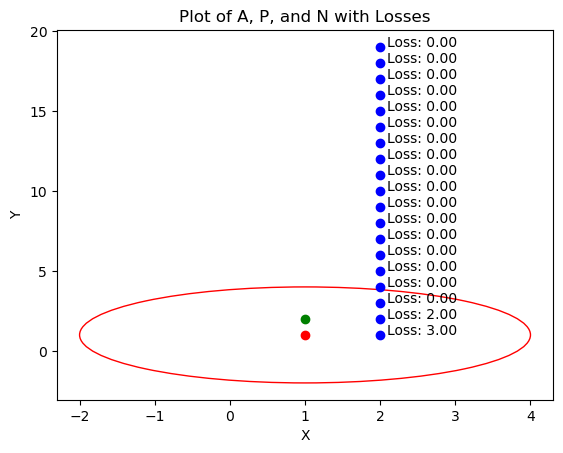

In [11]:
import matplotlib.pyplot as plt

# Plot A and P
plt.scatter(A[0], A[1], color='red', label='A')
plt.scatter(P[0], P[1], color='green', label='P')

# Plot the radius around A
circle = plt.Circle(A, m, color='red', fill=False)
plt.gca().add_patch(circle)

# Plot each N and label with corresponding loss
for i, n in enumerate(N):
    plt.scatter(n[0], n[1], color='blue', label='N')
    # plt.annotate(f'', (n[0], n[1]), textcoords="offset points", xytext=(0,10), ha='right')
    plt.annotate(f'Loss: {losses[i]:.2f}', (n[0], n[1]), textcoords="offset points", xytext=(+5,0), ha='left')

# Set the axis labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Plot of A, P, and N with Losses')

# Show the legend
# plt.legend()

# Show the plot
plt.show()

In [5]:
contrastive_loss(A,P,N[0],3)

d1=1.0,d2=1.00,m1=3, d1-d2+m1=3.00 


3.0